# 05 - Ablation Study
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

Isolates the contribution of each AC-PINN component on Burgers' equation
under noisy sparse data (the hardest condition).

| Model | Curriculum | Adaptive Weights |
|---|---|---|
| Vanilla PINN | ✗ | ✗ |
| + Curriculum only | ✓ | ✗ |
| + Adaptive Weights (ratio) only | ✗ | ratio |
| + Adaptive Weights (gradient) only | ✗ | gradient |
| Full AC-PINN (ratio) | ✓ | ratio |
| Full AC-PINN (gradient) | ✓ | gradient |
| **Full AC-PINN (both)** | ✓ | both |

In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, ACPINNSolver,
    BurgersFDM, Benchmark, save_metrics, save_history
)

PDE        = 'burgers'
LAYERS     = [2, 64, 64, 64, 64, 64, 1]
EPOCHS     = 10000
PDE_PARAMS = {'nu': 0.01/np.pi}
RESULTS    = '../results/burgers/'
FIGURES    = '../figures/burgers/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen  = NoisyDataGenerator(pde=PDE, **PDE_PARAMS)
# Hardest condition - noisy + sparse
data = gen.generate(N_ic=20, N_bc=20, N_f=2000, noise_eps=0.1)

fdm  = BurgersFDM(nx=256, nt=2000, nu=0.01/np.pi)
fdm.solve()
print(f'Device: {device} | Data ready')

BurgersFDM solved in 0.6969s
Device: cuda | Data ready


## Model 1 - Vanilla PINN (no curriculum, no adaptive weights)

In [2]:
m1 = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
h1 = m1.fit(data, epochs=EPOCHS, print_every=2000)
save_history(h1, RESULTS+'ablation_vanilla.npy')

D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch     0 | Total: 0.613490 | IC: 0.535170 | BC: 0.025950 | PDE: 0.010474


Epoch  2000 | Total: 0.124560 | IC: 0.089142 | BC: 0.014636 | PDE: 0.004156


Epoch  4000 | Total: 0.092582 | IC: 0.067355 | BC: 0.008426 | PDE: 0.003360


Epoch  6000 | Total: 0.052842 | IC: 0.038636 | BC: 0.007791 | PDE: 0.001283


Epoch  8000 | Total: 0.038307 | IC: 0.025850 | BC: 0.007557 | PDE: 0.000980



Training complete in 136.58s
Saved: ../results/burgers/ablation_vanilla.npy


## Model 2 - Curriculum Only (no adaptive weights)

In [3]:
# ACPINNSolver with ratio strategy but effectively fixed weights
# We set weight_update_every very high to disable adaptive updates
m2 = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                   weight_strategy='ratio')
h2 = m2.fit(data, epochs=EPOCHS, print_every=2000, weight_update_every=999999)
save_history(h2, RESULTS+'ablation_curriculum_only.npy')

Epoch     0 | Stage 1/4 | Total: 0.877888 | IC: 0.494062 | BC: 0.053481 | PDE: 0.066069 | λ=(1.00,1.00,5.00)


Epoch  2000 | Stage 1/4 | Total: 0.005846 | IC: 0.002179 | BC: 0.003657 | PDE: 0.000002 | λ=(1.00,1.00,5.00)


Epoch  4000 | Stage 2/4 | Total: 0.005341 | IC: 0.001831 | BC: 0.003397 | PDE: 0.000022 | λ=(1.00,1.00,5.00)


Epoch  6000 | Stage 3/4 | Total: 0.007421 | IC: 0.001700 | BC: 0.005023 | PDE: 0.000139 | λ=(1.00,1.00,5.00)


Epoch  8000 | Stage 4/4 | Total: 0.199773 | IC: 0.144180 | BC: 0.013648 | PDE: 0.008389 | λ=(1.00,1.00,5.00)



AC-PINN training complete in 149.17s
Saved: ../results/burgers/ablation_curriculum_only.npy


## Model 3 - Adaptive Weights (ratio) Only, no curriculum

In [4]:
# Disable curriculum by using very small resample pool
# and always sampling uniformly (stage 4 from epoch 0)
m3 = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                   weight_strategy='ratio', N_pool=2000, resample_every=1)
# Force stage 4 always by patching sampler thresholds
m3.sampler.STAGE_THRESHOLDS = [0.0, 0.0, 0.0, 1.0]
h3 = m3.fit(data, epochs=EPOCHS, print_every=2000)
save_history(h3, RESULTS+'ablation_ratio_weights_only.npy')

Epoch     0 | Stage 1/4 | Total: 0.478413 | IC: 0.388177 | BC: 0.078303 | PDE: 0.002387 | λ=(1.00,1.00,5.00)


Epoch  2000 | Stage 4/4 | Total: 0.804156 | IC: 0.006475 | BC: 0.024233 | PDE: 0.293829 | λ=(0.10,0.22,2.72)


Epoch  4000 | Stage 4/4 | Total: 0.753072 | IC: 0.009849 | BC: 0.025096 | PDE: 0.279759 | λ=(0.10,0.24,2.67)


Epoch  6000 | Stage 4/4 | Total: 0.753056 | IC: 0.004323 | BC: 0.010514 | PDE: 0.264528 | λ=(0.10,0.11,2.84)


Epoch  8000 | Stage 4/4 | Total: 0.719380 | IC: 0.003942 | BC: 0.012524 | PDE: 0.254549 | λ=(0.10,0.14,2.82)



AC-PINN training complete in 176.74s
Saved: ../results/burgers/ablation_ratio_weights_only.npy


## Model 4 - Adaptive Weights (gradient) Only, no curriculum

In [5]:
m4 = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                   weight_strategy='gradient', N_pool=2000, resample_every=1)
m4.sampler.STAGE_THRESHOLDS = [0.0, 0.0, 0.0, 1.0]
h4 = m4.fit(data, epochs=EPOCHS, print_every=2000)
save_history(h4, RESULTS+'ablation_gradient_weights_only.npy')

Epoch     0 | Stage 1/4 | Total: 0.585956 | IC: 0.549912 | BC: 0.031909 | PDE: 0.000827 | λ=(1.00,1.00,5.00)


Epoch  2000 | Stage 4/4 | Total: 0.143365 | IC: 0.024497 | BC: 0.005937 | PDE: 0.016885 | λ=(1.71,10.00,2.50)


Epoch  4000 | Stage 4/4 | Total: 0.059096 | IC: 0.002312 | BC: 0.002977 | PDE: 0.014184 | λ=(4.69,10.00,1.30)


Epoch  6000 | Stage 4/4 | Total: 0.033363 | IC: 0.000891 | BC: 0.002280 | PDE: 0.009520 | λ=(10.00,4.99,1.37)


Epoch  8000 | Stage 4/4 | Total: 0.034935 | IC: 0.000747 | BC: 0.002031 | PDE: 0.006199 | λ=(10.00,10.00,1.16)



AC-PINN training complete in 177.09s
Saved: ../results/burgers/ablation_gradient_weights_only.npy


## Model 5 - Full AC-PINN (ratio)

In [6]:
m5 = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                   weight_strategy='ratio', N_pool=20000, resample_every=500)
h5 = m5.fit(data, epochs=EPOCHS, print_every=2000)
save_history(h5, RESULTS+'ablation_full_ratio.npy')

Epoch     0 | Stage 1/4 | Total: 0.520065 | IC: 0.504888 | BC: 0.014872 | PDE: 0.000061 | λ=(1.00,1.00,5.00)


Epoch  2000 | Stage 1/4 | Total: 0.009396 | IC: 0.001869 | BC: 0.003958 | PDE: 0.000325 | λ=(0.91,1.93,0.16)


Epoch  4000 | Stage 2/4 | Total: 0.004497 | IC: 0.001423 | BC: 0.001720 | PDE: 0.000211 | λ=(1.27,1.54,0.19)


Epoch  6000 | Stage 3/4 | Total: 0.005147 | IC: 0.001371 | BC: 0.002194 | PDE: 0.001258 | λ=(0.85,1.36,0.78)


Epoch  8000 | Stage 4/4 | Total: 0.166196 | IC: 0.021945 | BC: 0.009834 | PDE: 0.071852 | λ=(0.64,0.28,2.08)



AC-PINN training complete in 149.30s
Saved: ../results/burgers/ablation_full_ratio.npy


## Model 6 - Full AC-PINN (gradient)

In [7]:
m6 = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                   weight_strategy='gradient', N_pool=20000, resample_every=500)
h6 = m6.fit(data, epochs=EPOCHS, print_every=2000)
save_history(h6, RESULTS+'ablation_full_gradient.npy')

Epoch     0 | Stage 1/4 | Total: 0.462028 | IC: 0.407563 | BC: 0.054271 | PDE: 0.000039 | λ=(1.00,1.00,5.00)


Epoch  2000 | Stage 1/4 | Total: 0.019436 | IC: 0.001865 | BC: 0.006660 | PDE: 0.000083 | λ=(5.35,1.30,10.00)


Epoch  4000 | Stage 2/4 | Total: 0.022478 | IC: 0.001276 | BC: 0.006270 | PDE: 0.000273 | λ=(4.27,2.60,2.62)


Epoch  6000 | Stage 3/4 | Total: 0.022305 | IC: 0.001026 | BC: 0.005189 | PDE: 0.001723 | λ=(4.95,1.68,4.94)


Epoch  8000 | Stage 4/4 | Total: 0.259250 | IC: 0.068384 | BC: 0.007740 | PDE: 0.023607 | λ=(1.51,10.00,3.34)



AC-PINN training complete in 149.11s
Saved: ../results/burgers/ablation_full_gradient.npy


## Model 7 - Full AC-PINN (both) - Best Configuration

In [8]:
m7 = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                   weight_strategy='both', N_pool=20000, resample_every=500)
h7 = m7.fit(data, epochs=EPOCHS, print_every=2000)
save_history(h7, RESULTS+'ablation_full_both.npy')

Epoch     0 | Stage 1/4 | Total: 0.530956 | IC: 0.438485 | BC: 0.041255 | PDE: 0.010243 | λ=(1.00,1.00,5.00)


Epoch  2000 | Stage 1/4 | Total: 0.015244 | IC: 0.002761 | BC: 0.004125 | PDE: 0.000004 | λ=(1.71,2.54,10.00)


Epoch  4000 | Stage 2/4 | Total: 0.011975 | IC: 0.001645 | BC: 0.002288 | PDE: 0.000021 | λ=(5.32,1.32,10.00)


Epoch  6000 | Stage 3/4 | Total: 0.010044 | IC: 0.001290 | BC: 0.004302 | PDE: 0.000512 | λ=(0.63,2.11,0.25)


Epoch  8000 | Stage 4/4 | Total: 0.144295 | IC: 0.059387 | BC: 0.013703 | PDE: 0.043524 | λ=(1.53,0.35,1.12)



AC-PINN training complete in 149.85s
Saved: ../results/burgers/ablation_full_both.npy


## Ablation Benchmark Table

In [9]:
models = [
    ('Vanilla PINN',                    m1),
    ('+ Curriculum only',               m2),
    ('+ Ratio weights only',            m3),
    ('+ Gradient weights only',         m4),
    ('Full AC-PINN (ratio)',            m5),
    ('Full AC-PINN (gradient)',         m6),
    ('Full AC-PINN (both) ← Best',     m7),
]

bench = Benchmark(fdm, nx=200, nt=100)
for name, model in models:
    bench.add(name, model)
bench.run()

ablation_metrics = bench.compare_metrics()
save_metrics(ablation_metrics, RESULTS+'ablation_metrics.npy')

  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla PINN                0.698827   1.987775   0.178504   0.425002
  + Curriculum only           0.540353   1.143233   0.210746   0.328623
  + Ratio weights only        0.324950   0.863741   0.122444   0.197623
  + Gradient weights only     0.362893   1.870035   0.071437   0.220699
  Full AC-PINN (ratio)        0.319261   1.000688   0.117123   0.194163
  Full AC-PINN (gradient)     0.531736   1.259786   0.201098   0.323383
  Full AC-PINN (both) ← Best   0.613590   0.957070   0.282918   0.373164
Saved: ../results/burgers/ablation_metrics.npy


## Ablation Loss Curves

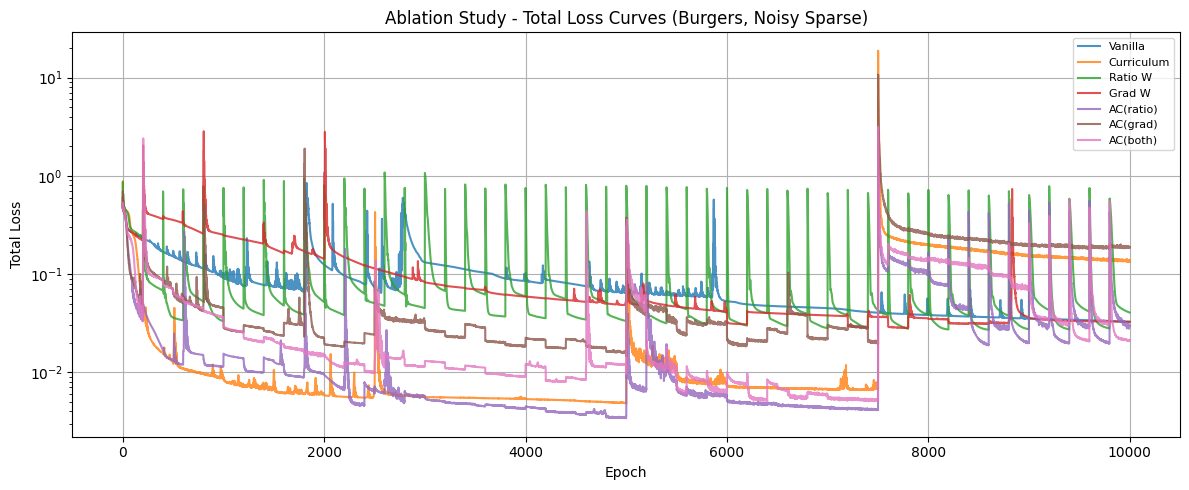

Ablation study complete.


In [10]:
histories = [h1, h2, h3, h4, h5, h6, h7]
labels    = ['Vanilla', 'Curriculum', 'Ratio W', 'Grad W',
             'AC(ratio)', 'AC(grad)', 'AC(both)']

plt.figure(figsize=(12, 5))
for h, lbl in zip(histories, labels):
    plt.plot(h['total'], label=lbl, alpha=0.8)
plt.yscale('log')
plt.xlabel('Epoch'); plt.ylabel('Total Loss')
plt.title('Ablation Study - Total Loss Curves (Burgers, Noisy Sparse)')
plt.legend(fontsize=8); plt.grid(True)
plt.tight_layout()
plt.savefig(FIGURES+'ablation_loss_curves.png', dpi=150)
plt.show()
print('Ablation study complete.')